# Notebook 04 — Machine Learning Supervisado: XGBoost y LightGBM
**TFM · Predicción de Ventas para Optimización de Stock**
Familias: PVC · PE · PE-X (reticulado)

**Objetivos:**
1. Feature engineering temporal: lags, medias móviles, variables de calendario
2. Ajuste de XGBoost y LightGBM con TimeSeriesSplit CV
3. Tuning de hiperparámetros con RandomizedSearchCV
4. Predicción recursiva multistep con intervalos bootstrap
5. Interpretabilidad con valores SHAP
6. Comparativa con los modelos estadísticos del Notebook 03

In [17]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import xgboost as xgb
import lightgbm as lgb
import shap

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    mean_absolute_percentage_error
)

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

FAMILIAS = None
COLORES  = {'PVC': '#2ecc71', 'PE': '#3498db', 'PE-X': '#e74c3c'}
H        = 12     # horizonte de prediccion (meses)
ALPHA    = 0.05   # nivel IC bootstrap
N_BOOT   = 500    # replicas bootstrap para IC
N_ITER   = 30     # iteraciones RandomizedSearchCV

print('Imports OK')
print(f'XGBoost {xgb.__version__}  |  LightGBM {lgb.__version__}')

Imports OK
XGBoost 3.2.0  |  LightGBM 4.6.0


## 1. Carga de datos

In [18]:
df = pd.read_excel('../data/processed/datos.xlsx')
df['FECHA'] = pd.to_datetime(df['FECHA'])

df_ventas = df[df['TIPO_OPERACION'] == 'VENTA'].copy()
df_ventas['PERIODO'] = df_ventas['FECHA'].dt.to_period('M')

ventas_mensual = (
    df_ventas
    .groupby(['PERIODO', 'FAMILIA'])['IMPORTE_NETO']
    .sum()
    .unstack('FAMILIA')
    .sort_index()
    .fillna(0)
)

FAMILIAS = ventas_mensual.columns.tolist()
print(f'Periodo: {ventas_mensual.index[0]} -> {ventas_mensual.index[-1]}')
print(f'Total meses: {len(ventas_mensual)}')
print(f'Familias: {FAMILIAS}')
ventas_mensual.describe().round(0)

Periodo: 2010-12 -> 2026-02
Total meses: 164
Familias: [106, 124, 233]


FAMILIA,106,124,233
count,164.0,164.0,164.0
mean,8826.0,32570.0,61089.0
std,20567.0,42984.0,47727.0
min,-144.0,0.0,0.0
25%,0.0,0.0,22388.0
50%,0.0,13160.0,51496.0
75%,7335.0,54024.0,86019.0
max,119307.0,196518.0,220501.0


## 2. Feature Engineering Temporal

Los modelos de árboles no tienen memoria temporal intrínseca.
Toda la estructura de la serie debe codificarse explícitamente como columnas.

Se crean tres bloques de features:
- **Lags**: valores pasados de la propia serie (memoria directa)
- **Estadísticos de ventana móvil**: media y desviación sobre ventanas de 3, 6 y 12 meses
- **Calendario**: mes, trimestre, año y codificación circular (sin/cos) del mes

In [20]:
def crear_features(serie, lags=[1, 2, 3, 6, 12], ventanas=[3, 6, 12]):
    """
    Construye un DataFrame de features a partir de una serie temporal.

    IMPORTANTE: todos los lags y medias moviles usan shift(>=1)
    para evitar data leakage: en el momento de predecir Y_t
    solo se conocen Y_{t-1}, Y_{t-2}, ...

    Parameters
    ----------
    serie    : pd.Series con indice de periodo mensual
    lags     : retardos a incluir como features
    ventanas : tamanos de ventana para estadisticos moviles

    Returns
    -------
    pd.DataFrame con columnas [y, lag_*, ma_*, std_*, features_calendario]
    """
    df = pd.DataFrame({'y': serie.values}, index=serie.index)

    # --- Lags ---
    for lag in lags:
        df[f'lag_{lag}'] = df['y'].shift(lag)

    # --- Medias y desviaciones moviles (shift(1) para no filtrar el presente) ---
    for v in ventanas:
        df[f'ma_{v}']  = df['y'].shift(1).rolling(v).mean()
        df[f'std_{v}'] = df['y'].shift(1).rolling(v).std()

    # --- Variables de calendario ---
    df['mes']       = [p.month       for p in serie.index]
    df['trimestre'] = [((p.month-1)//3)+1 for p in serie.index]
    df['ano']       = [p.year        for p in serie.index]

    # Codificacion circular del mes (evita la discontinuidad dic->ene)
    df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12)
    df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12)

    # Tendencia lineal global
    df['trend'] = np.arange(len(df))

    return df.dropna()  # eliminamos las primeras filas con NaN por los lags


# Crear features para cada familia y mostrar resumen
datasets = {}
for familia in FAMILIAS:
    df_f = crear_features(ventas_mensual[familia])
    datasets[familia] = df_f
    print(f'[{familia}]  filas={len(df_f)}  features={df_f.shape[1]-1}')

print('\nColumnas de features:')
print(list(datasets[FAMILIAS[0]].drop(columns='y').columns))

[106]  filas=152  features=17
[124]  filas=152  features=17
[233]  filas=152  features=17

Columnas de features:
['lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'ma_3', 'std_3', 'ma_6', 'std_6', 'ma_12', 'std_12', 'mes', 'trimestre', 'ano', 'mes_sin', 'mes_cos', 'trend']


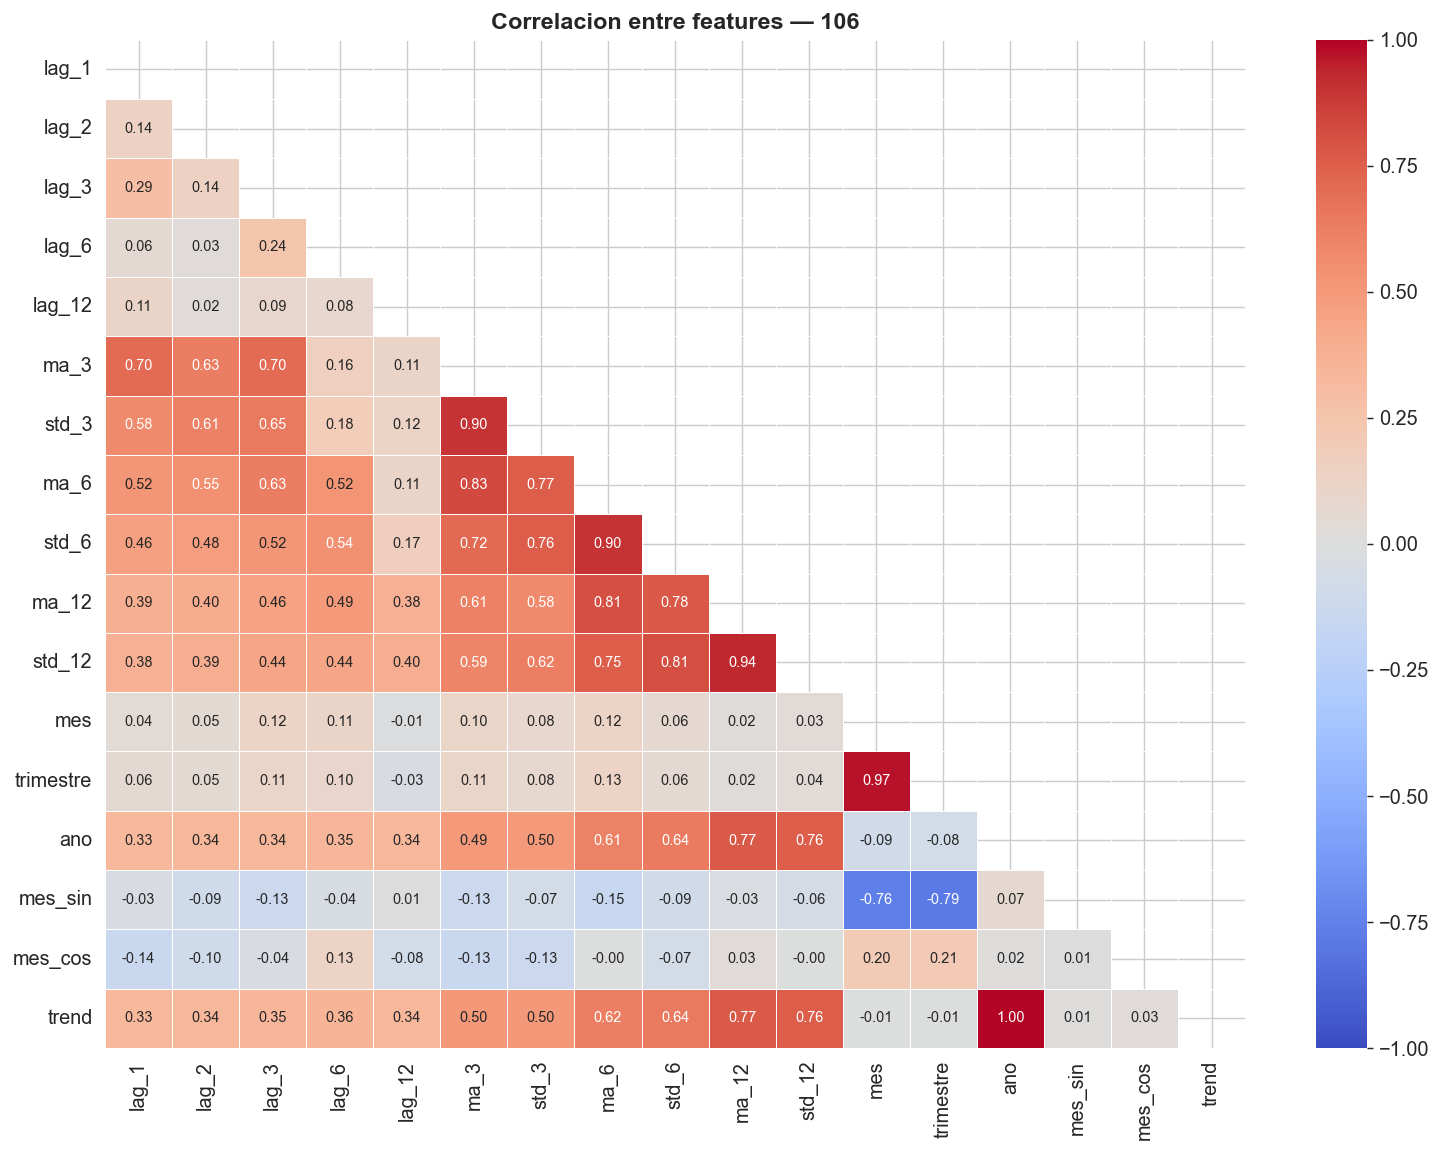

Figura guardada: figuras/04_correlacion_features.pdf


In [22]:
# Visualizar la matriz de correlacion de features (familia PVC como ejemplo)
familia_ej = FAMILIAS[0]
feat_corr  = datasets[familia_ej].drop(columns='y').corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(feat_corr, dtype=bool))
sns.heatmap(
    feat_corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, annot_kws={'size': 8}
)
plt.title(f'Correlacion entre features — {familia_ej}',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../figuras/04_correlacion_features.pdf', bbox_inches='tight')
plt.show()
print('Figura guardada: figuras/04_correlacion_features.pdf')

## 3. Funciones auxiliares

In [23]:
def smape(actual, forecast):
    return 100 * np.mean(
        2 * np.abs(forecast - actual) / (np.abs(actual) + np.abs(forecast) + 1e-9)
    )

def calcular_metricas(actual, forecast, modelo, familia):
    return {
        'Modelo'  : modelo,
        'Familia' : familia,
        'RMSE'    : round(np.sqrt(mean_squared_error(actual, forecast)), 2),
        'MAE'     : round(mean_absolute_error(actual, forecast), 2),
        'MAPE_%'  : round(mean_absolute_percentage_error(actual, forecast) * 100, 2),
        'SMAPE_%' : round(smape(actual, forecast), 2),
    }


def forecast_recursivo(model, X_train, y_train, X_test, n_steps,
                        lags=[1, 2, 3, 6, 12]):
    """
    Prediccion recursiva multistep.

    En cada paso h predice Y_{T+h} usando como lags las predicciones
    anteriores Y_hat_{T+1},...,Y_hat_{T+h-1} cuando el dato real
    no esta disponible.
    """
    history    = list(y_train.values)
    feat_names = list(X_train.columns)
    preds      = []

    for step in range(n_steps):
        row = X_test.iloc[step].copy()
        combined = history + preds   # historia real + predicciones acumuladas

        for lag in lags:
            col = f'lag_{lag}'
            if col in feat_names:
                idx_hist = -(lag - step) if lag > step else None
                if lag <= step:
                    row[col] = preds[step - lag]
                # Si lag > step usamos el valor real ya en X_test (no se modifica)

        pred = float(model.predict(row.values.reshape(1, -1))[0])
        preds.append(pred)

    return np.array(preds)


def bootstrap_intervals(model, X_train, y_train, X_test,
                         n_boot=N_BOOT, alpha=ALPHA):
    """
    Intervalos de prediccion por bootstrap de residuos.

    Asume que los residuos del conjunto de entrenamiento son representativos
    del error de prediccion futura.
    """
    residuals = y_train.values - model.predict(X_train)
    preds     = model.predict(X_test)
    lower, upper = [], []

    rng = np.random.default_rng(42)
    for i in range(len(X_test)):
        boot = preds[i] + rng.choice(residuals, n_boot, replace=True)
        lower.append(np.percentile(boot, 100 * alpha / 2))
        upper.append(np.percentile(boot, 100 * (1 - alpha / 2)))

    return np.array(lower), np.array(upper)


print('Funciones auxiliares definidas.')

Funciones auxiliares definidas.


## 4. Tuning de hiperparámetros con TimeSeriesSplit

Usamos `RandomizedSearchCV` con `TimeSeriesSplit(n_splits=5)` como estrategia de CV.
Esto garantiza que cada fold de validacion siempre es temporalmente posterior
al fold de entrenamiento.

In [24]:
param_dist_xgb = {
    'n_estimators'    : [100, 200, 300, 400, 500],
    'max_depth'       : [3, 4, 5, 6],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.15],
    'subsample'       : [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5, 7],
    'gamma'           : [0, 0.1, 0.2, 0.3],
    'reg_alpha'       : [0, 0.01, 0.1],
    'reg_lambda'      : [1, 1.5, 2],
}

param_dist_lgb = {
    'n_estimators'    : [100, 200, 300, 400, 500],
    'max_depth'       : [3, 4, 5, 6, -1],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.15],
    'num_leaves'      : [15, 31, 63, 127],
    'subsample'       : [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'min_child_samples': [5, 10, 20, 30],
    'reg_alpha'       : [0, 0.01, 0.1],
    'reg_lambda'      : [0, 0.01, 0.1],
}

tscv = TimeSeriesSplit(n_splits=5)

mejores_params = {'XGBoost': {}, 'LightGBM': {}}

for familia in FAMILIAS:
    df_f   = datasets[familia]
    X_all  = df_f.drop(columns='y')
    y_all  = df_f['y']
    X_tr   = X_all.iloc[:-H]
    y_tr   = y_all.iloc[:-H]

    print(f'\nTuning {familia}...')

    # --- XGBoost ---
    rscv_xgb = RandomizedSearchCV(
        xgb.XGBRegressor(random_state=42, verbosity=0),
        param_dist_xgb, n_iter=N_ITER, cv=tscv,
        scoring='neg_mean_absolute_percentage_error',
        random_state=42, n_jobs=-1
    )
    rscv_xgb.fit(X_tr, y_tr)
    mejores_params['XGBoost'][familia] = rscv_xgb.best_params_
    cv_mape_xgb = -rscv_xgb.best_score_ * 100
    print(f'  XGBoost  CV-MAPE={cv_mape_xgb:.2f}%  params={rscv_xgb.best_params_}')

    # --- LightGBM ---
    rscv_lgb = RandomizedSearchCV(
        lgb.LGBMRegressor(random_state=42, verbose=-1),
        param_dist_lgb, n_iter=N_ITER, cv=tscv,
        scoring='neg_mean_absolute_percentage_error',
        random_state=42, n_jobs=-1
    )
    rscv_lgb.fit(X_tr, y_tr)
    mejores_params['LightGBM'][familia] = rscv_lgb.best_params_
    cv_mape_lgb = -rscv_lgb.best_score_ * 100
    print(f'  LightGBM CV-MAPE={cv_mape_lgb:.2f}%  params={rscv_lgb.best_params_}')

print('\nTuning completado.')


Tuning 106...
  XGBoost  CV-MAPE=951924870791543652352.00%  params={'subsample': 1.0, 'reg_lambda': 2, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.7}
  LightGBM CV-MAPE=719958316265924984832.00%  params={'subsample': 0.8, 'reg_lambda': 0.01, 'reg_alpha': 0.01, 'num_leaves': 127, 'n_estimators': 100, 'min_child_samples': 20, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.7}

Tuning 124...
  XGBoost  CV-MAPE=538213751765633728512.00%  params={'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.9}
  LightGBM CV-MAPE=275348896969643884544.00%  params={'subsample': 1.0, 'reg_lambda': 0.1, 'reg_alpha': 0.01, 'num_leaves': 127, 'n_estimators': 500, 'min_child_samples': 30, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

Tuning 233...
  XGBoost  CV-MAPE=61

## 5. Entrenamiento final y predicción walk-forward

In [25]:
resultados_xgb   = []
resultados_lgb   = []
predicciones_ml  = {}    # {familia: {XGBoost: {...}, LightGBM: {...}}}
modelos_xgb      = {}
modelos_lgb      = {}

for familia in FAMILIAS:
    df_f  = datasets[familia]
    X_all = df_f.drop(columns='y')
    y_all = df_f['y']
    X_tr, X_te = X_all.iloc[:-H], X_all.iloc[-H:]
    y_tr, y_te = y_all.iloc[:-H], y_all.iloc[-H:]

    predicciones_ml[familia] = {}

    for nombre, ModelClass, params in [
        ('XGBoost',  xgb.XGBRegressor,  {**mejores_params['XGBoost'][familia],
                                          'random_state': 42, 'verbosity': 0}),
        ('LightGBM', lgb.LGBMRegressor, {**mejores_params['LightGBM'][familia],
                                          'random_state': 42, 'verbose': -1}),
    ]:
        model = ModelClass(**params)
        model.fit(X_tr, y_tr)

        if nombre == 'XGBoost':
            modelos_xgb[familia] = model
        else:
            modelos_lgb[familia] = model

        # Prediccion directa (1 paso: XGBoost predice los 12 a la vez)
        y_pred = model.predict(X_te)

        # Intervalos bootstrap
        lo, hi = bootstrap_intervals(model, X_tr, y_tr, X_te)

        metricas = calcular_metricas(y_te.values, y_pred, nombre, familia)
        if nombre == 'XGBoost':
            resultados_xgb.append(metricas)
        else:
            resultados_lgb.append(metricas)

        predicciones_ml[familia][nombre] = {
            'test'     : y_te.values,
            'fc_mean'  : y_pred,
            'fc_lower' : lo,
            'fc_upper' : hi,
        }

        print(f'[{familia}] {nombre:8s}  '
              f'RMSE={metricas["RMSE"]:>10.2f}  '
              f'MAPE={metricas["MAPE_%"]:>6.2f}%  '
              f'SMAPE={metricas["SMAPE_%"]:>6.2f}%')

print('\nEntrenamiento y prediccion completados.')

[106] XGBoost   RMSE=  42263.50  MAPE=915.00%  SMAPE=113.33%
[106] LightGBM  RMSE=  42095.77  MAPE=557.90%  SMAPE=118.07%
[124] XGBoost   RMSE=  57368.63  MAPE= 44.21%  SMAPE= 61.22%
[124] LightGBM  RMSE=  43415.13  MAPE= 32.88%  SMAPE= 38.93%
[233] XGBoost   RMSE=  37852.09  MAPE= 94.74%  SMAPE= 59.91%
[233] LightGBM  RMSE=  48030.31  MAPE=103.07%  SMAPE= 84.66%

Entrenamiento y prediccion completados.


## 6. Visualización de predicciones

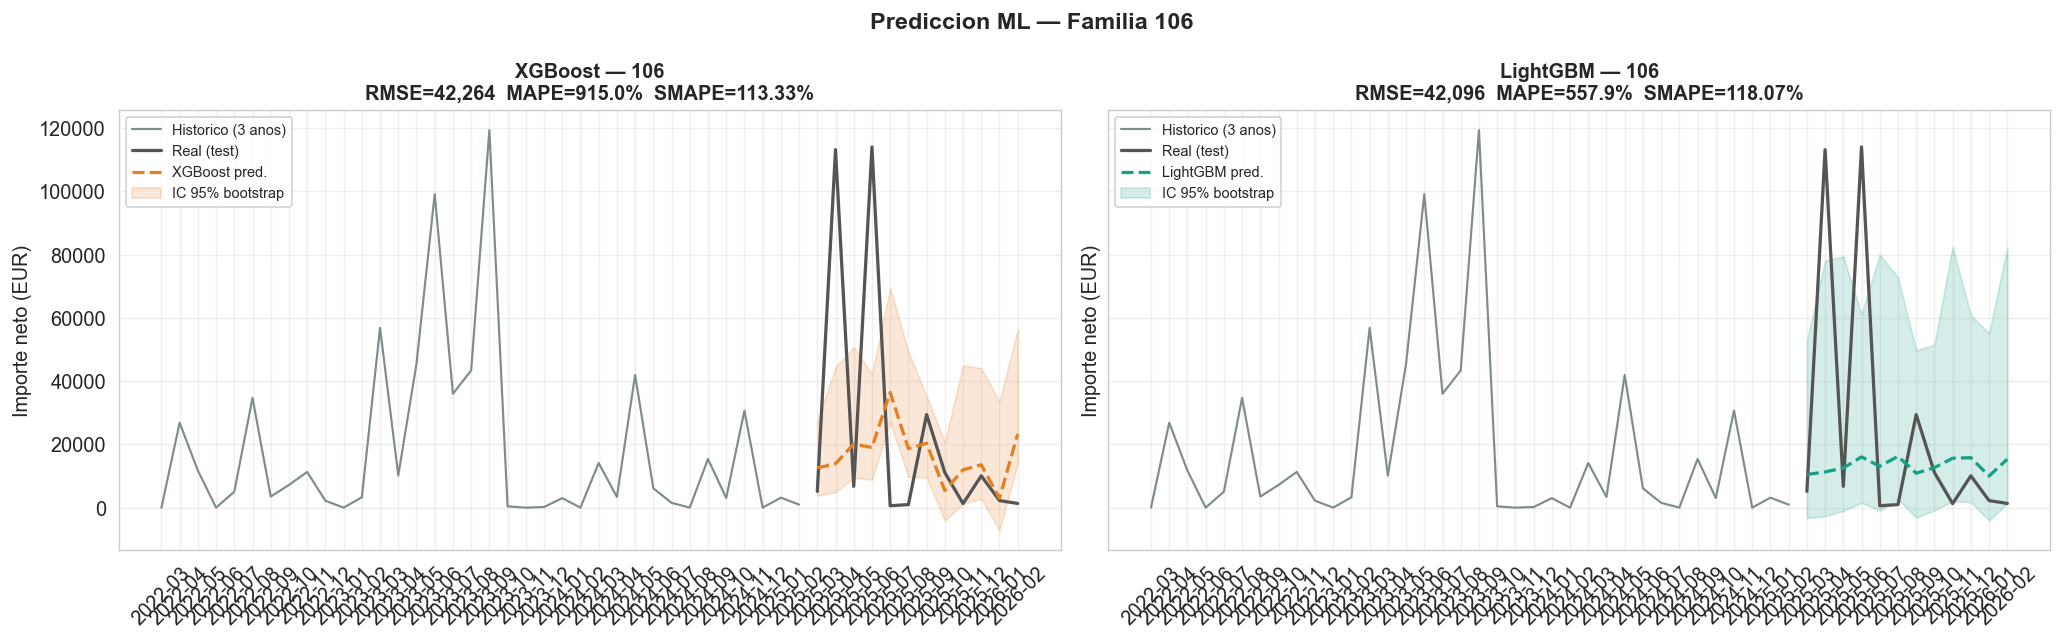

Figura guardada: ../figuras/04_prediccion_ML_106.pdf


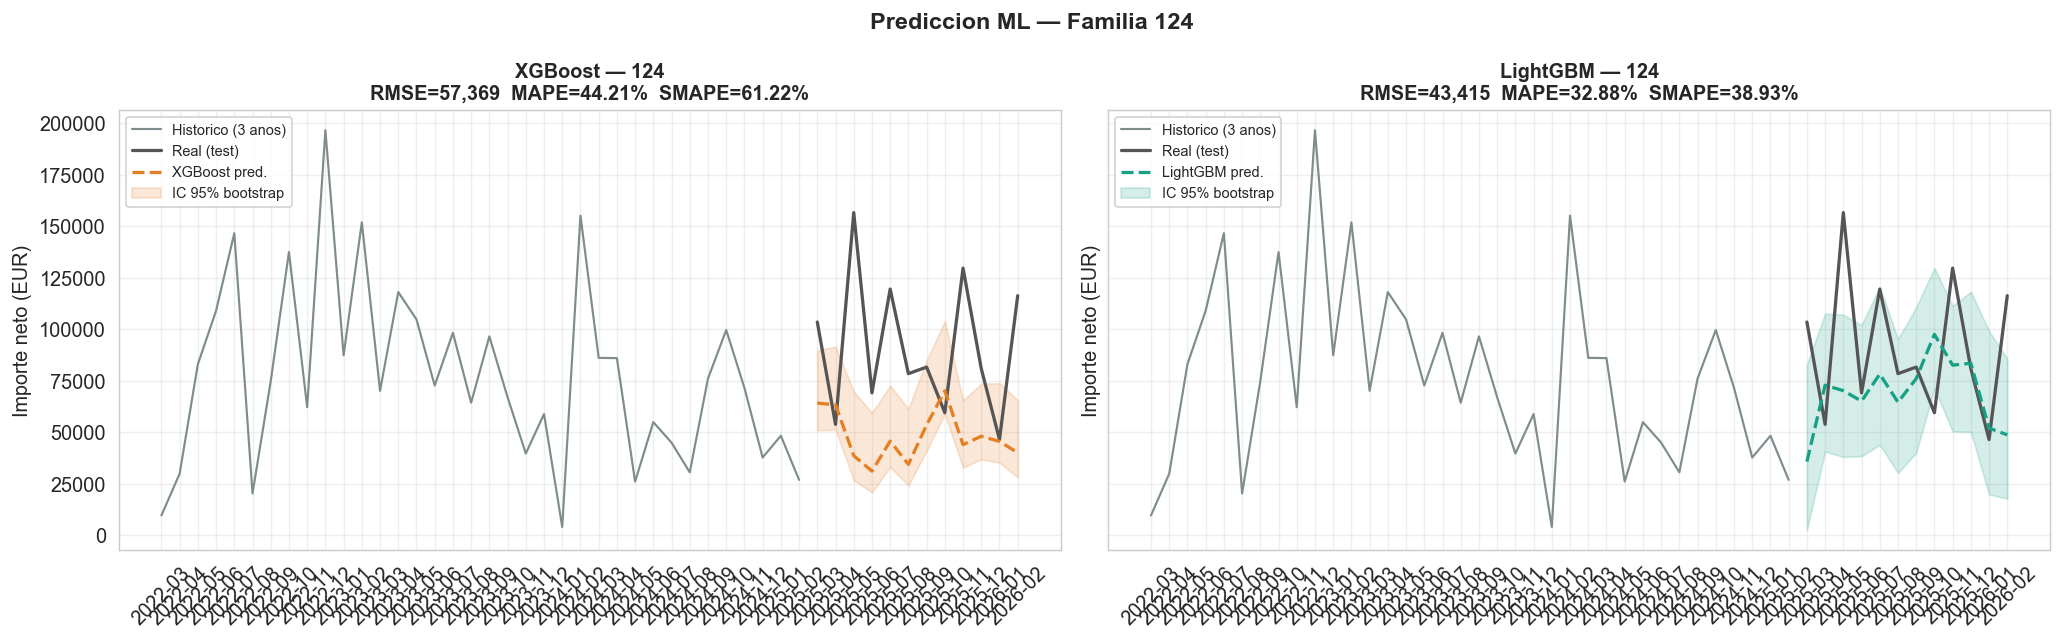

Figura guardada: ../figuras/04_prediccion_ML_124.pdf


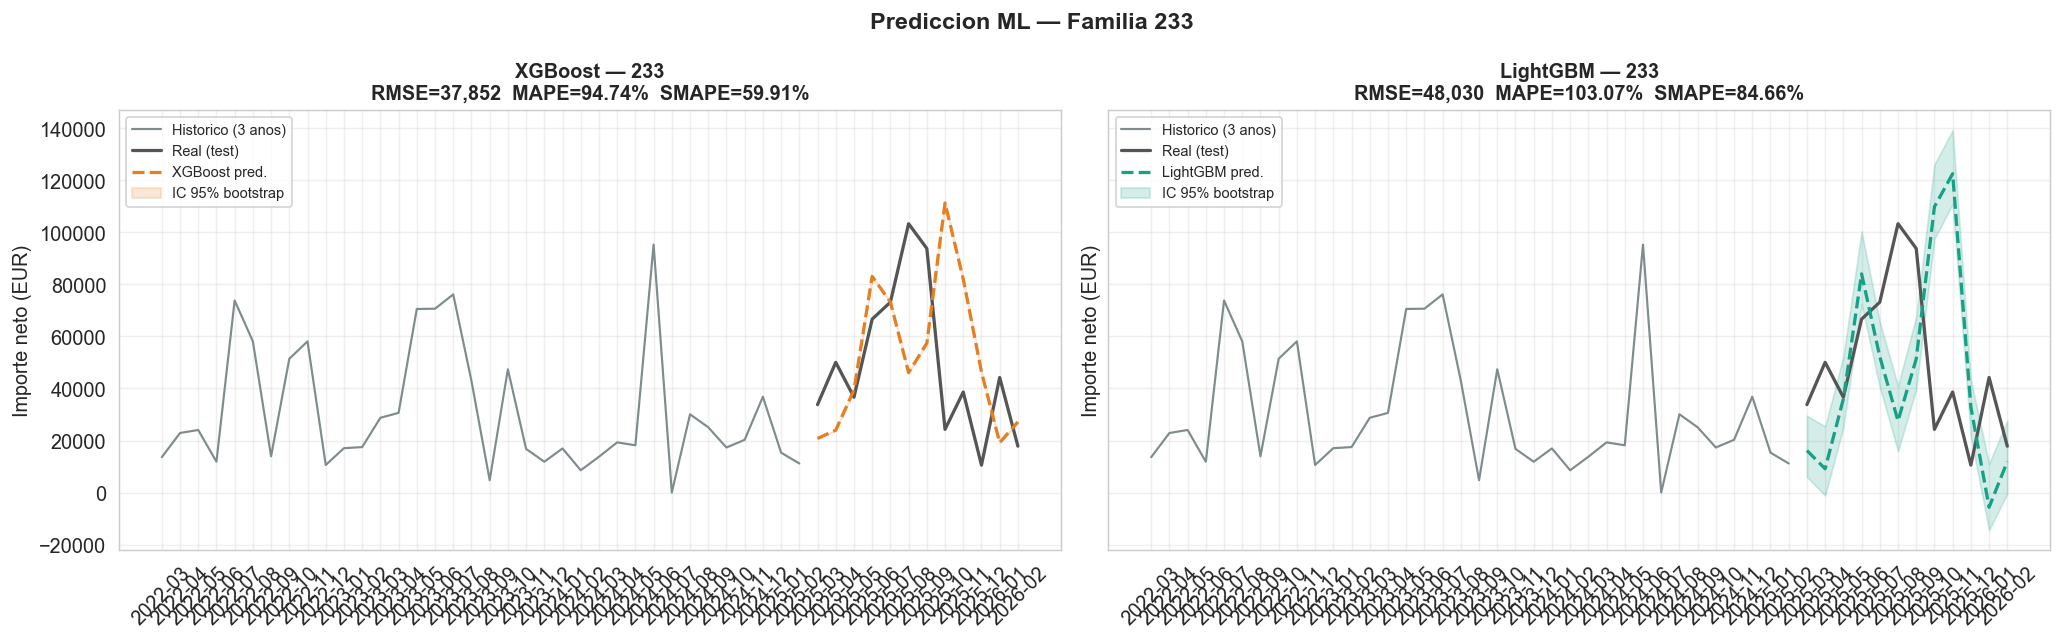

Figura guardada: ../figuras/04_prediccion_ML_233.pdf


In [26]:
MODELOS_COLORES = {'XGBoost': '#e67e22', 'LightGBM': '#16a085'}

for familia in FAMILIAS:
    serie    = ventas_mensual[familia].values
    n        = len(serie)
    test_idx = ventas_mensual.index[-H:].astype(str)

    ctx_start = n - H - 36
    ctx_idx   = ventas_mensual.index[ctx_start:].astype(str)
    ctx_train = serie[ctx_start:-H]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

    for ax, nombre in zip(axes, ['XGBoost', 'LightGBM']):
        pred  = predicciones_ml[familia][nombre]
        color = MODELOS_COLORES[nombre]

        ax.plot(list(ctx_idx[:36]), ctx_train,
                color='#7f8c8d', lw=1.2, label='Historico (3 anos)')
        ax.plot(list(test_idx), pred['test'],
                color=COLORES.get(familia,'#555'), lw=1.8, label='Real (test)')
        ax.plot(list(test_idx), pred['fc_mean'],
                color=color, lw=1.8, ls='--', label=f'{nombre} pred.')
        ax.fill_between(list(test_idx),
                        pred['fc_lower'], pred['fc_upper'],
                        alpha=0.18, color=color,
                        label=f'IC {int((1-ALPHA)*100)}% bootstrap')

        res = resultados_xgb if nombre == 'XGBoost' else resultados_lgb
        m   = next(r for r in res if r['Familia'] == familia)
        ax.set_title(
            f'{nombre} — {familia}\n'
            f'RMSE={m["RMSE"]:,.0f}  MAPE={m["MAPE_%"]}%  SMAPE={m["SMAPE_%"]}%',
            fontweight='bold', fontsize=11
        )
        ax.set_ylabel('Importe neto (EUR)')
        ax.legend(loc='upper left', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)

    plt.suptitle(f'Prediccion ML — Familia {familia}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    fname = f'../figuras/04_prediccion_ML_{familia}.pdf'
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    print(f'Figura guardada: {fname}')

## 7. Interpretabilidad con SHAP

Los valores SHAP (SHapley Additive exPlanations) cuantifican la contribucion
de cada feature a cada prediccion individual, con garantia de consistencia y
eficiencia (Lundberg & Lee, 2017).

Para modelos de árbol, `shap.TreeExplainer` calcula los valores exactos
en tiempo polinomial.

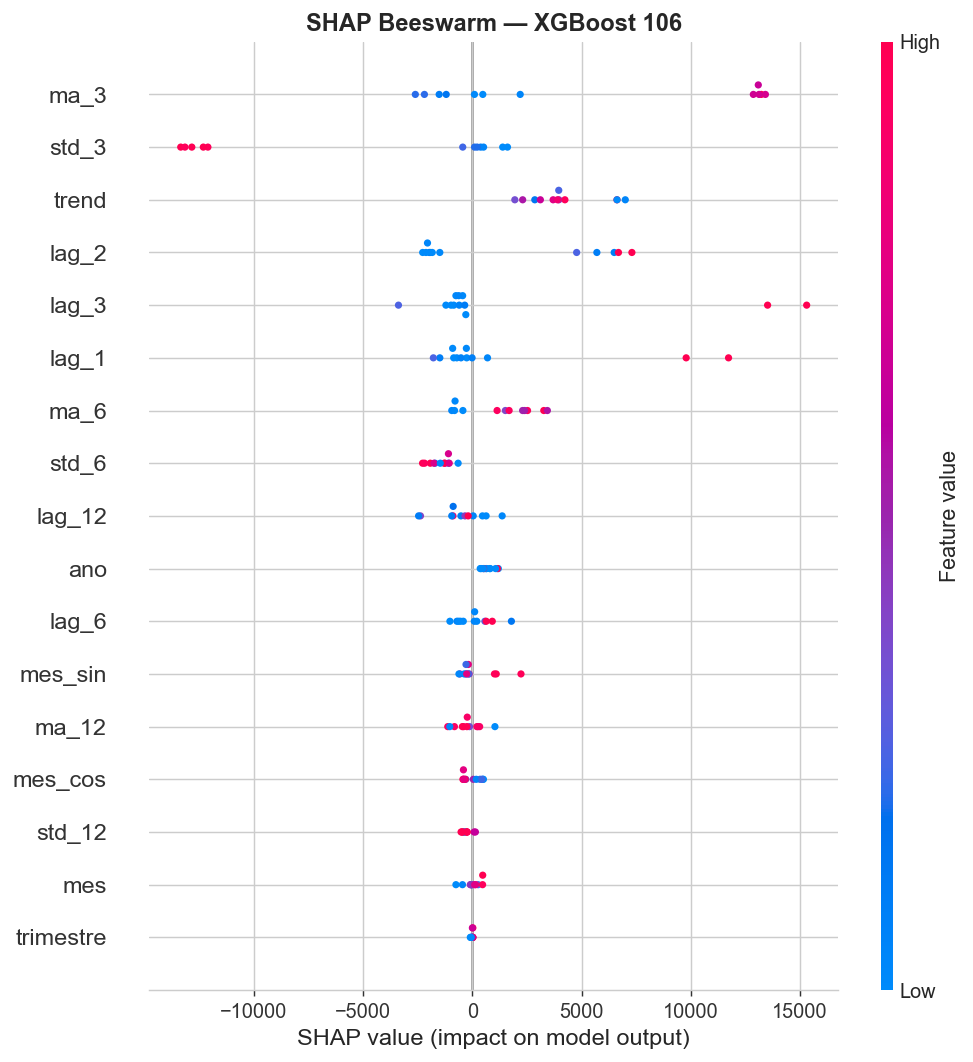

Figura guardada: ../figuras/04_shap_beeswarm_106.pdf


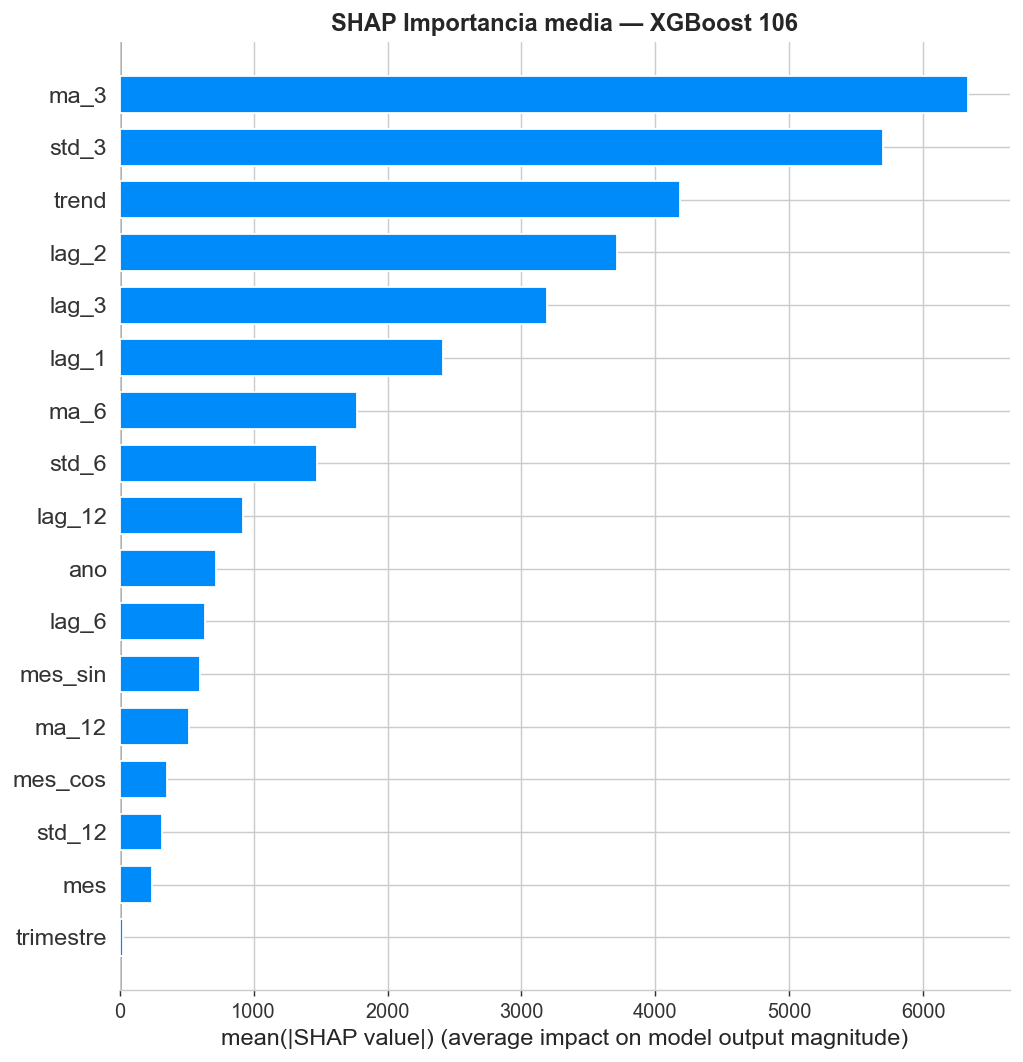

Figura guardada: ../figuras/04_shap_bar_106.pdf



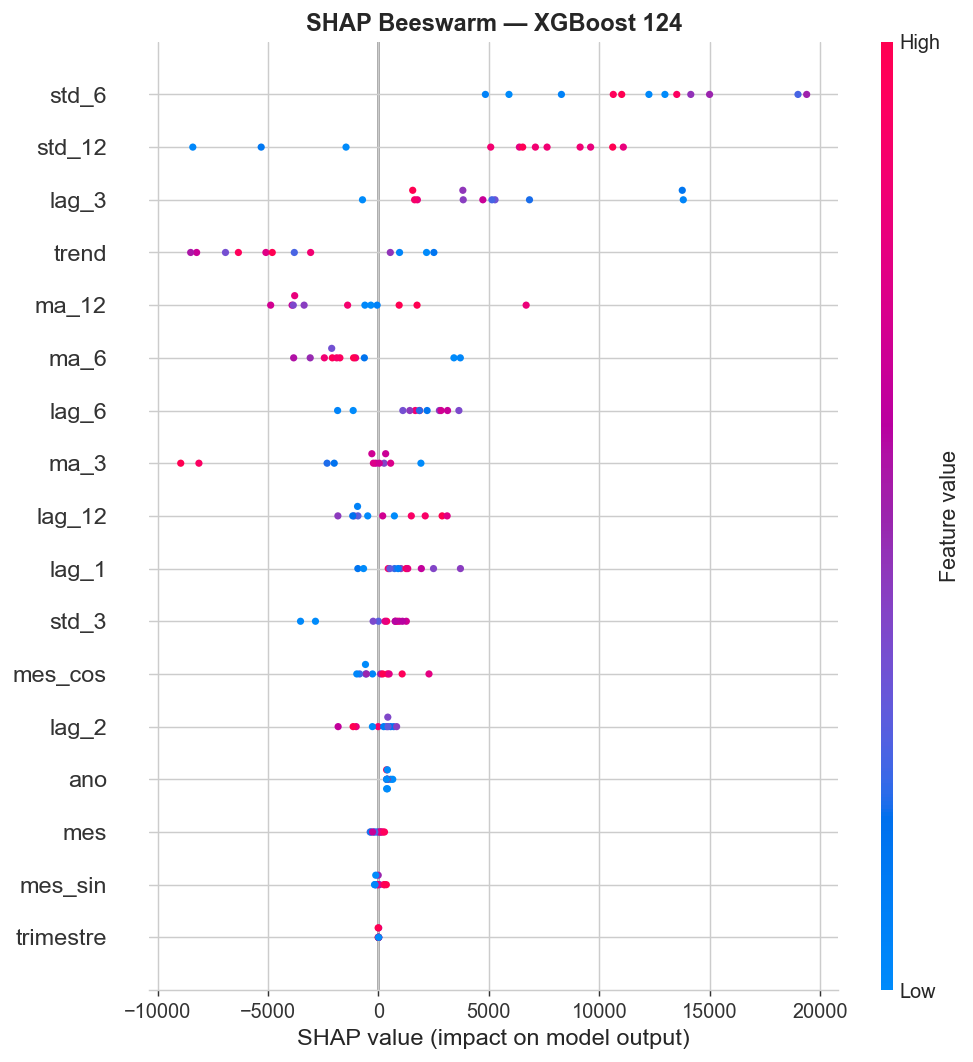

Figura guardada: ../figuras/04_shap_beeswarm_124.pdf


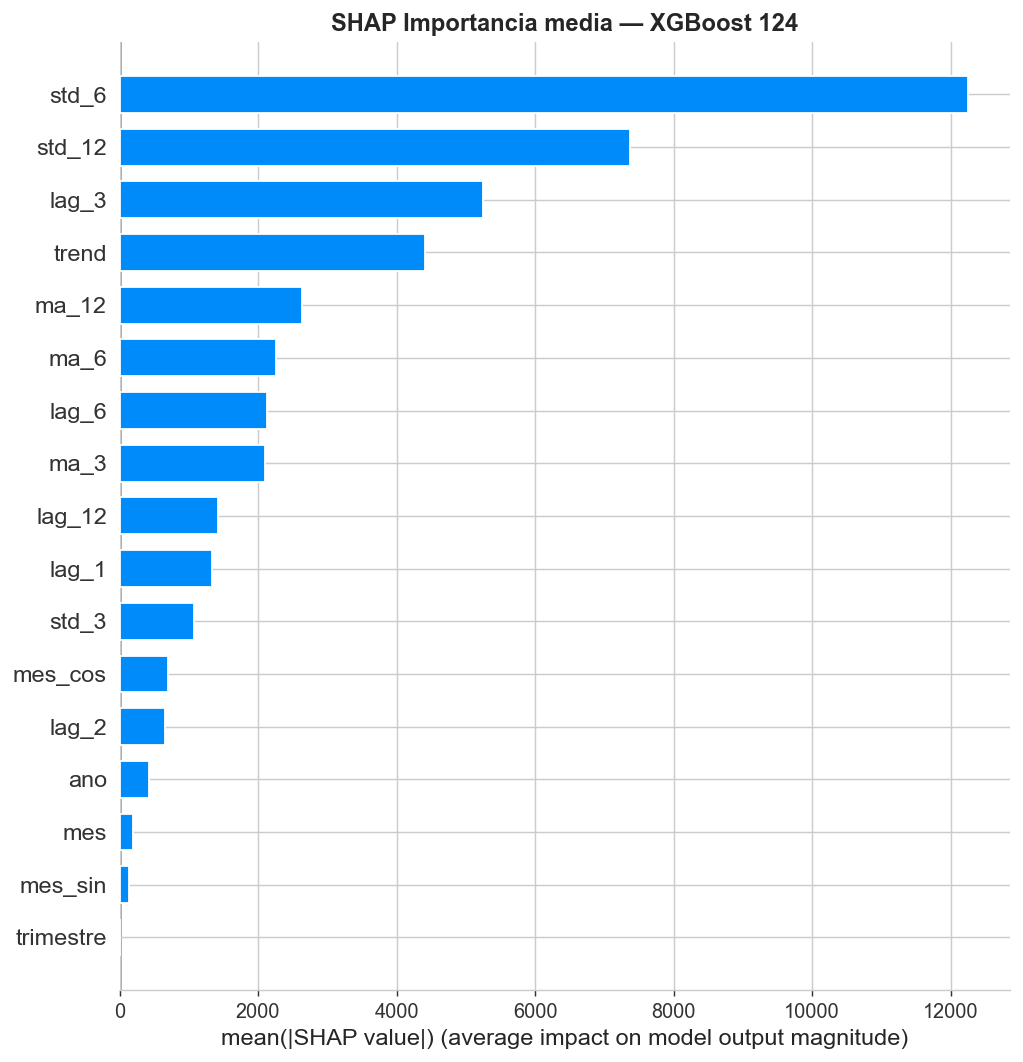

Figura guardada: ../figuras/04_shap_bar_124.pdf



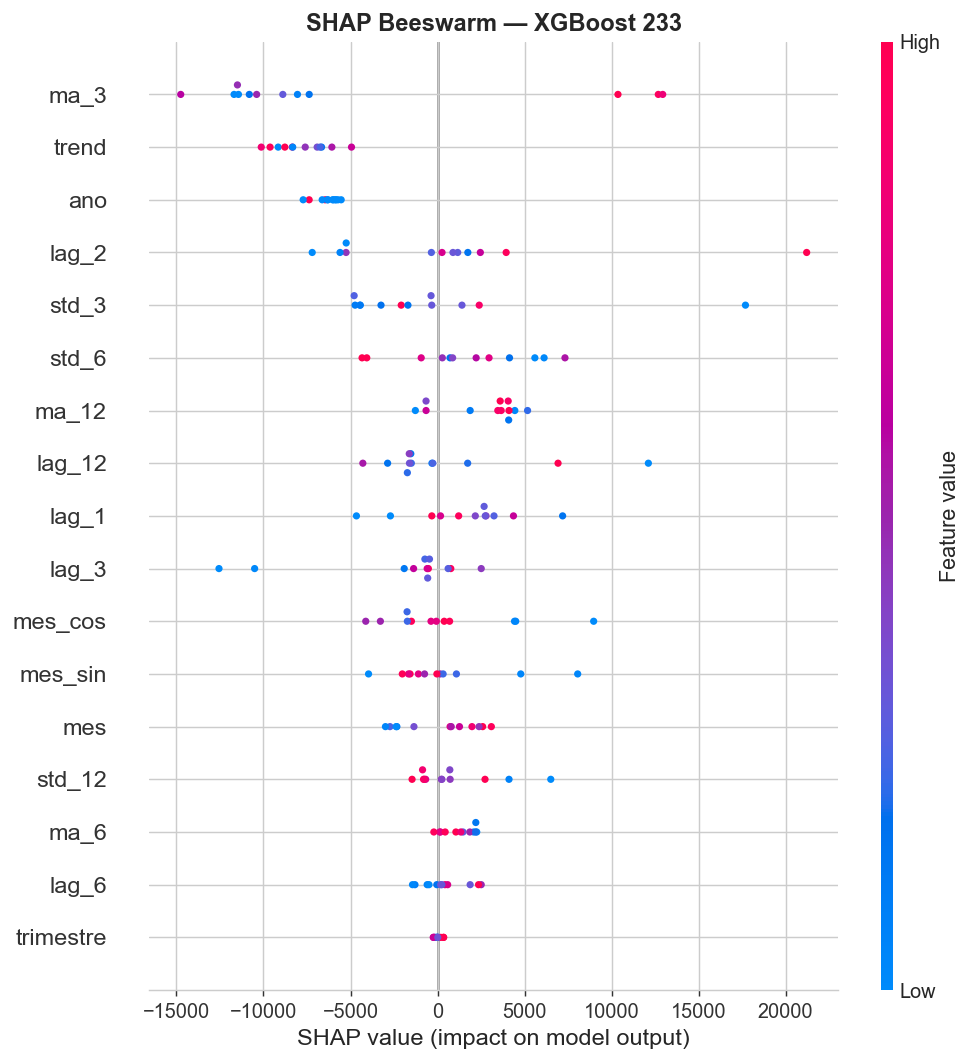

Figura guardada: ../figuras/04_shap_beeswarm_233.pdf


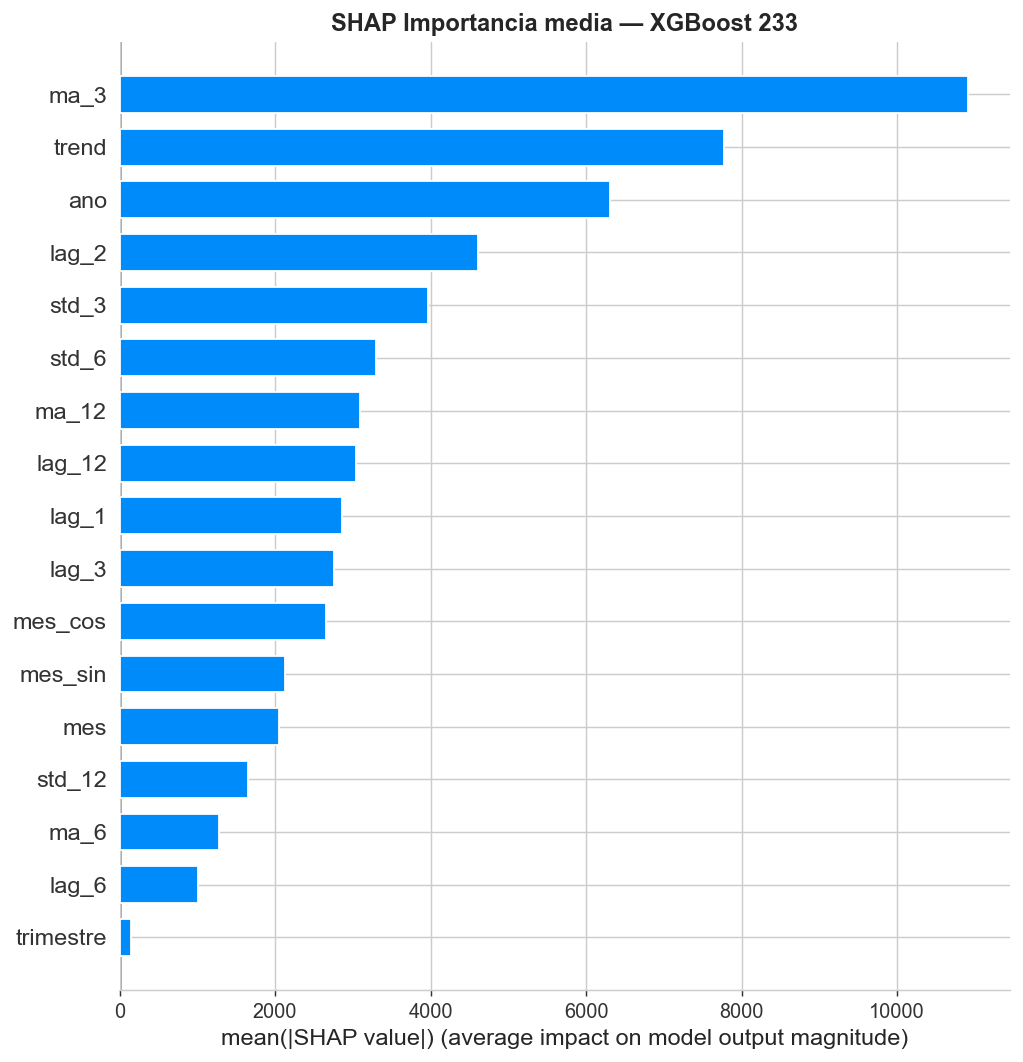

Figura guardada: ../figuras/04_shap_bar_233.pdf



In [27]:
shap_resultados = {}

for familia in FAMILIAS:
    df_f  = datasets[familia]
    X_all = df_f.drop(columns='y')
    X_tr  = X_all.iloc[:-H]
    X_te  = X_all.iloc[-H:]
    model = modelos_xgb[familia]

    # Calcular SHAP sobre el conjunto de TEST
    explainer  = shap.TreeExplainer(model)
    shap_vals  = explainer.shap_values(X_te)
    shap_resultados[familia] = (shap_vals, X_te)

    # -- Grafico 1: Beeswarm (importancia + direccion del efecto) --
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_vals, X_te, show=False, plot_type='dot')
    plt.title(f'SHAP Beeswarm — XGBoost {familia}', fontweight='bold')
    plt.tight_layout()
    fname1 = f'../figuras/04_shap_beeswarm_{familia}.pdf'
    plt.savefig(fname1, bbox_inches='tight')
    plt.show()
    print(f'Figura guardada: {fname1}')

    # -- Grafico 2: Bar plot (importancia media absoluta) --
    plt.figure(figsize=(9, 5))
    shap.summary_plot(shap_vals, X_te, show=False, plot_type='bar')
    plt.title(f'SHAP Importancia media — XGBoost {familia}', fontweight='bold')
    plt.tight_layout()
    fname2 = f'../figuras/04_shap_bar_{familia}.pdf'
    plt.savefig(fname2, bbox_inches='tight')
    plt.show()
    print(f'Figura guardada: {fname2}\n')

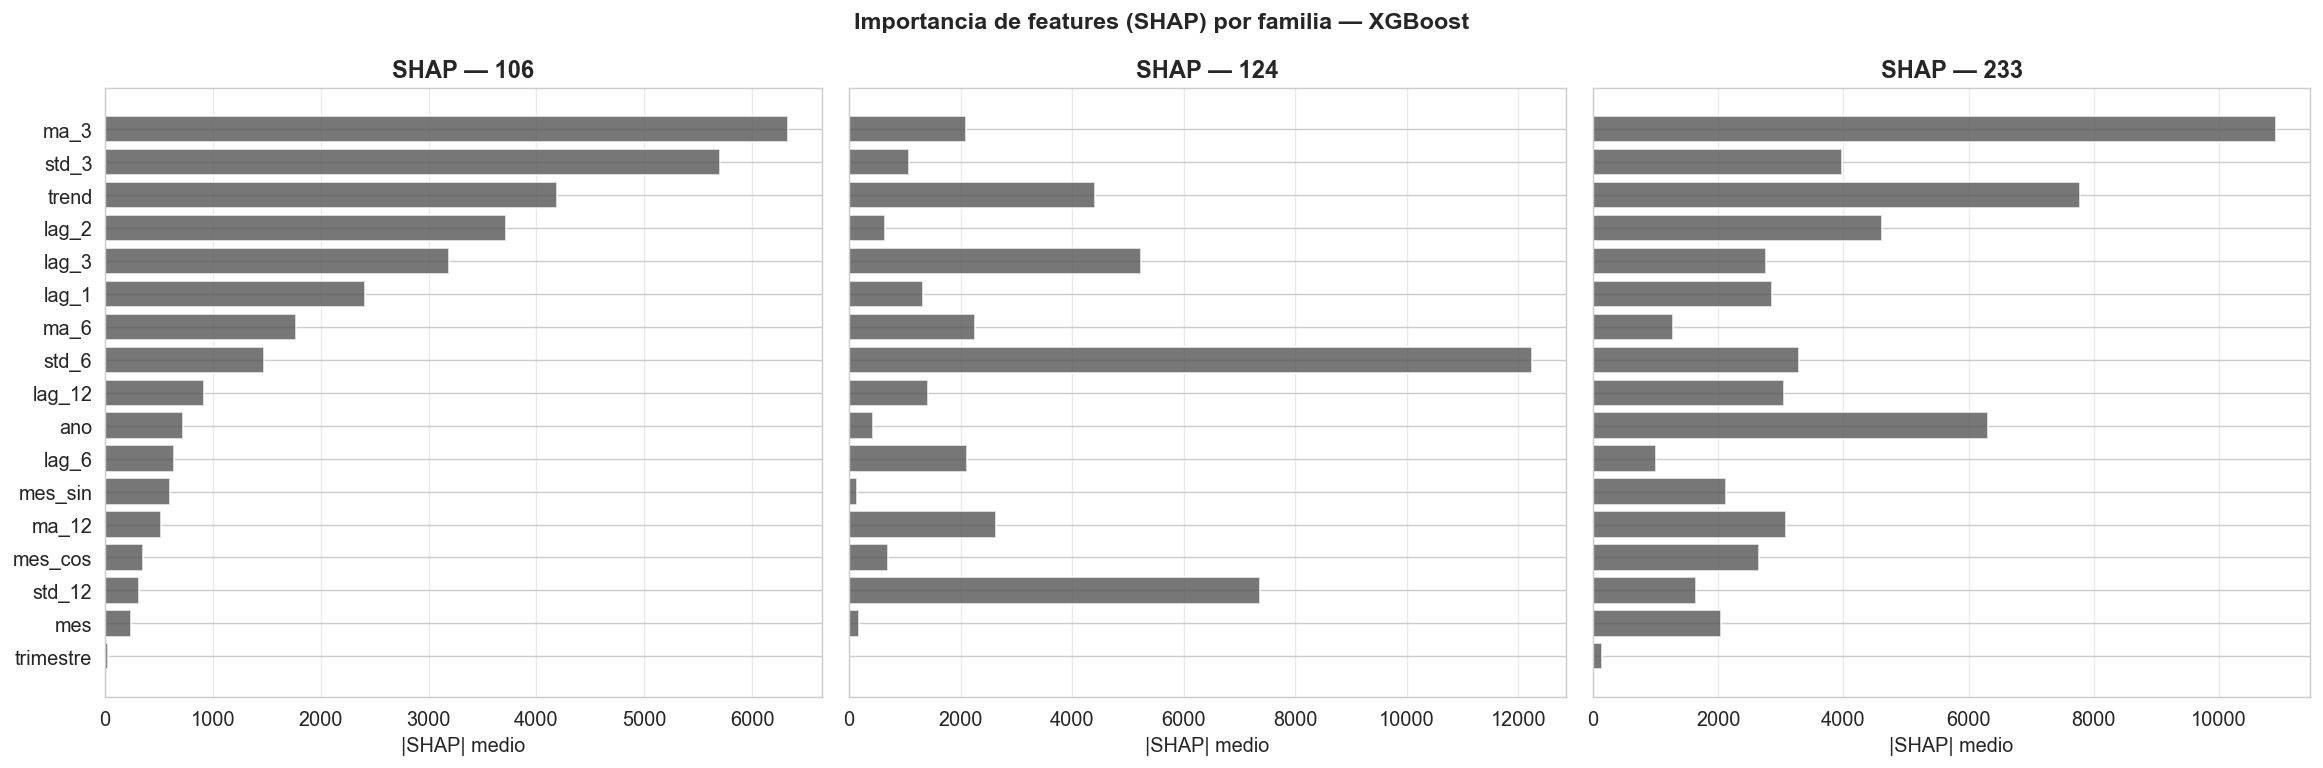

Figura guardada: figuras/04_shap_resumen.pdf


In [28]:
# Grafico resumen: importancia SHAP media por feature y familia
fig, axes = plt.subplots(1, len(FAMILIAS),
                          figsize=(6 * len(FAMILIAS), 6), sharey=True)
if len(FAMILIAS) == 1:
    axes = [axes]

for ax, familia in zip(axes, FAMILIAS):
    shap_vals, X_te = shap_resultados[familia]
    importancia = pd.Series(
        np.abs(shap_vals).mean(axis=0),
        index=X_te.columns
    ).sort_values(ascending=True)

    color = COLORES.get(familia, '#555')
    ax.barh(importancia.index, importancia.values, color=color, alpha=0.8)
    ax.set_title(f'SHAP — {familia}', fontweight='bold')
    ax.set_xlabel('|SHAP| medio')
    ax.grid(axis='x', alpha=0.4)

plt.suptitle('Importancia de features (SHAP) por familia — XGBoost',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figuras/04_shap_resumen.pdf', bbox_inches='tight')
plt.show()
print('Figura guardada: figuras/04_shap_resumen.pdf')

## 8. Comparativa global con modelos del Notebook 03

In [29]:
# Cargar metricas del Notebook 03
try:
    df_03 = pd.read_csv('../data/processed/03_metricas_SARIMA_Prophet.csv')
except FileNotFoundError:
    print('AVISO: ejecutar primero el Notebook 03 para tener las metricas de SARIMA/Prophet.')
    df_03 = pd.DataFrame(columns=['Modelo','Familia','RMSE','MAE','MAPE_%','SMAPE_%'])

df_04 = pd.DataFrame(resultados_xgb + resultados_lgb)
df_global = pd.concat([df_03, df_04], ignore_index=True)

# Tabla pivot: familias x modelos, metrica = MAPE
tabla_mape = df_global.pivot_table(
    index='Familia', columns='Modelo', values='MAPE_%'
).round(2)

print('MAPE (%) — todos los modelos:')
print(tabla_mape.to_string())

tabla_smape = df_global.pivot_table(
    index='Familia', columns='Modelo', values='SMAPE_%'
).round(2)
print('\nSMAPE (%) — todos los modelos:')
print(tabla_smape.to_string())

df_global.to_csv('../data/processed/04_metricas_global.csv', index=False)
print('\nCSV guardado: data/processed/04_metricas_global.csv')

MAPE (%) — todos los modelos:
Modelo   LightGBM  Prophet  SARIMA  XGBoost
Familia                                    
106        557.90  1110.49  136.97   915.00
124         32.88    37.21   34.36    44.21
233        103.07    60.85   60.40    94.74

SMAPE (%) — todos los modelos:
Modelo   LightGBM  Prophet  SARIMA  XGBoost
Familia                                    
106        118.07   131.46  130.30   113.33
124         38.93    49.60   44.12    61.22
233         84.66    77.92   71.70    59.91

CSV guardado: data/processed/04_metricas_global.csv


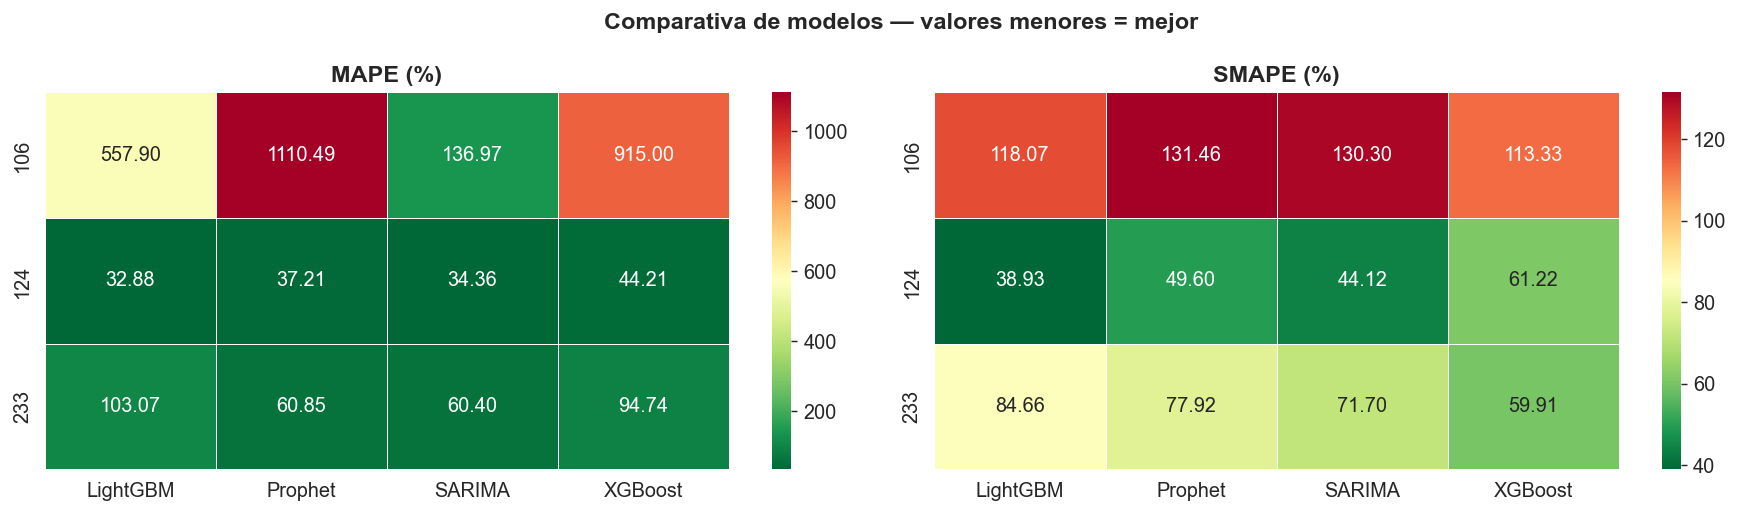

Figura guardada: figuras/04_heatmap_comparativa.pdf


In [30]:
# Grafico heatmap de MAPE por familia y modelo
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (titulo, tabla) in zip(axes, [
    ('MAPE (%)',  tabla_mape),
    ('SMAPE (%)', tabla_smape)
]):
    sns.heatmap(
        tabla, annot=True, fmt='.2f', cmap='RdYlGn_r',
        ax=ax, linewidths=0.5, annot_kws={'size': 11}
    )
    ax.set_title(titulo, fontweight='bold', fontsize=13)
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.suptitle('Comparativa de modelos — valores menores = mejor',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figuras/04_heatmap_comparativa.pdf', bbox_inches='tight')
plt.show()
print('Figura guardada: figuras/04_heatmap_comparativa.pdf')

## 9. Exportación de predicciones

In [31]:
# Combinar predicciones XGBoost y LightGBM con las del Notebook 03
fechas_test = ventas_mensual.index[-H:].to_timestamp()
rows = []

for familia in FAMILIAS:
    for nombre in ['XGBoost', 'LightGBM']:
        pred = predicciones_ml[familia][nombre]
        for i, fecha in enumerate(fechas_test):
            rows.append({
                'FECHA'       : fecha,
                'FAMILIA'     : familia,
                'MODELO'      : nombre,
                'REAL'        : pred['test'][i],
                'PRED'        : pred['fc_mean'][i],
                'IC_LOWER'    : pred['fc_lower'][i],
                'IC_UPPER'    : pred['fc_upper'][i],
            })

df_pred_ml = pd.DataFrame(rows)
df_pred_ml.to_csv('../data/processed/04_predicciones_ML.csv', index=False)
print('Predicciones exportadas: data/processed/04_predicciones_ML.csv')
df_pred_ml.head(6)

Predicciones exportadas: data/processed/04_predicciones_ML.csv


,FECHA,FAMILIA,MODELO,REAL,PRED,IC_LOWER,IC_UPPER
0,2025-03-01,106,XGBoost,5166.55,12539.476562,3760.282276,27487.805781
1,2025-04-01,106,XGBoost,113156.60,13891.755859,4947.616172,44425.618672
2,2025-05-01,106,XGBoost,6728.37,20133.955078,9420.657227,50667.817891
3,2025-06-01,106,XGBoost,114013.30,18996.761719,8877.935645,42235.810519
4,2025-07-01,106,XGBoost,598.08,36395.894531,26934.116211,69447.163594
5,2025-08-01,106,XGBoost,964.80,18662.048828,9717.909141,49195.911641


In [32]:
print('=' * 65)
print('RESUMEN NOTEBOOK 04')
print('=' * 65)

for familia in FAMILIAS:
    mx = next(r for r in resultados_xgb if r['Familia'] == familia)
    ml = next(r for r in resultados_lgb if r['Familia'] == familia)
    print(f'\n[{familia}]')
    print(f'  XGBoost   RMSE={mx["RMSE"]:>10,.2f}  MAPE={mx["MAPE_%"]:>6.2f}%  SMAPE={mx["SMAPE_%"]:>6.2f}%')
    print(f'  LightGBM  RMSE={ml["RMSE"]:>10,.2f}  MAPE={ml["MAPE_%"]:>6.2f}%  SMAPE={ml["SMAPE_%"]:>6.2f}%')
    mejor = 'XGBoost' if mx['MAPE_%'] < ml['MAPE_%'] else 'LightGBM'
    print(f'  -> Mejor (MAPE): {mejor}')

print('\n' + '=' * 65)
print('Proximo: Notebook 05 — LSTM (Deep Learning)')

RESUMEN NOTEBOOK 04

[106]
  XGBoost   RMSE= 42,263.50  MAPE=915.00%  SMAPE=113.33%
  LightGBM  RMSE= 42,095.77  MAPE=557.90%  SMAPE=118.07%
  -> Mejor (MAPE): LightGBM

[124]
  XGBoost   RMSE= 57,368.63  MAPE= 44.21%  SMAPE= 61.22%
  LightGBM  RMSE= 43,415.13  MAPE= 32.88%  SMAPE= 38.93%
  -> Mejor (MAPE): LightGBM

[233]
  XGBoost   RMSE= 37,852.09  MAPE= 94.74%  SMAPE= 59.91%
  LightGBM  RMSE= 48,030.31  MAPE=103.07%  SMAPE= 84.66%
  -> Mejor (MAPE): XGBoost

Proximo: Notebook 05 — LSTM (Deep Learning)
